In [1]:
# --- Colab setup -------------------------------------------------------------
# Upload fyp_data.zip to Google Drive under MyDrive/fyp/ before running this.
# Runtime > Change runtime type > T4 GPU.
import os, zipfile, shutil, glob
from google.colab import drive
drive.mount('/content/drive')

# locate the fyp folder, tolerating a stray leading/trailing space in its name
import glob as _g
_c = [p for p in _g.glob('/content/drive/MyDrive/*')
      if os.path.isdir(p) and os.path.basename(p).strip().lower() == 'fyp']
if not _c:
    raise FileNotFoundError('No folder named fyp at the top level of My Drive. '
                            'Top level contains: ' + str(sorted(os.listdir('/content/drive/MyDrive'))))
DRIVE = _c[0]
print('using Drive folder:', repr(DRIVE))
ROOT  = '/content/fyp'
WORK  = ROOT + '/'
for d in ('processed', 'models', 'Dataset', 'plots'):
    os.makedirs(f'{ROOT}/{d}', exist_ok=True)

if not os.path.exists(f'{ROOT}/processed/master_all_cities.csv'):
    with zipfile.ZipFile(f'{DRIVE}/fyp_data.zip') as z:
        z.extractall(f'{ROOT}/_unzip')
    for p in glob.glob(f'{ROOT}/_unzip/**/*.csv', recursive=True):
        name = os.path.basename(p)
        dest = 'processed' if name == 'master_all_cities.csv' else 'Dataset'
        shutil.move(p, f'{ROOT}/{dest}/{name}')
    shutil.rmtree(f'{ROOT}/_unzip', ignore_errors=True)

DATA_DIR = f'{ROOT}/Dataset/'
print('city files:', sorted(os.listdir(DATA_DIR)))
print('master    :', round(os.path.getsize(f'{ROOT}/processed/master_all_cities.csv') / 1e6, 1), 'MB')

# The Kaggle notebooks called this to hunt for the data; here it is already known.
def find_csv_dir(root=None):
    return DATA_DIR

import torch
print('torch', torch.__version__, '| cuda:', torch.cuda.is_available(),
      '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')


Mounted at /content/drive
using Drive folder: '/content/drive/MyDrive/fyp'
city files: ['jena_germany_2000_2009_hourly.csv', 'london_uk_2000_2009_hourly.csv', 'newyork_usa_2000_2009_hourly.csv', 'sydney_australia_2000_2009_hourly.csv', 'tokyo_japan_2000_2009_hourly.csv']
master    : 162.1 MB
torch 2.11.0+cu128 | cuda: True | Tesla T4


> **Note on outputs**
>
> **Where this ran:** locally, before I moved the heavy training to cloud GPUs. The saved outputs were cleared at some point, so the cells below show code only.
>
> **What it produced:** the LSTM baseline, test MAE 1.39 C. That figure is the *untuned* LSTM - notebook 17 later searches its hyperparameters properly and gets it down to 1.266.
>
> **Where to verify:** processed/model_results.csv, and the tuned result in processed/search_summary.csv.

> **Note on this notebook**
>
> **Where this ran:** Google Colab, on a T4 GPU. The outputs below are from that run.
>
> **Scope:** this is the first LSTM baseline and it is trained and evaluated on Jena
> alone, over a 24-hour horizon. It reports 1.3584 degrees. That figure is not the
> same quantity as the recurrent-network results in Chapter 4, which are averaged
> across all five cities; the two should not be read against each other.
>
> **Status:** the baseline this notebook established was later superseded. The tuned
> five-city recurrent network is in `notebooks/17_hyperparameter_search.ipynb` and
> `scripts/21_lstm_converged.py`, and those are the figures the dissertation reports.
> This notebook is kept as the starting point of that line of work.

## 1. Install & Import

In [2]:
# !pip install torch scikit-learn pandas numpy matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings, os
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')
os.makedirs(f'{ROOT}/models', exist_ok=True)
os.makedirs(f'{ROOT}/plots', exist_ok=True)

Device: cuda
PyTorch version: 2.11.0+cu128


## 2. Load & Prepare Jena Data

In [4]:
# Load master dataset, filter Jena only for baseline
master = pd.read_csv(f'{ROOT}/processed/master_all_cities.csv',
                     parse_dates=['time'], low_memory=False)

jena = master[master['city'] == 'Jena'].copy().reset_index(drop=True)
jena = jena.sort_values('time').reset_index(drop=True)

print(f'Jena dataset: {len(jena):,} rows')
print(f'Date range: {jena["time"].min()} to {jena["time"].max()}')
jena.head(3)

Jena dataset: 87,648 rows
Date range: 2000-01-02 00:00:00 to 2009-12-31 23:00:00


,time,temperature,humidity,dew_point,precipitation,rain,wind_speed,wind_direction,wind_gusts,pressure_msl,...,dayofyear_cos,wind_u,wind_v,temp_lag_1h,temp_lag_3h,temp_lag_6h,temp_lag_24h,temp_roll_6h,temp_roll_24h,temp_diff_1h
0,2000-01-02 00:00:00,3.5,98,3.2,0.0,0.0,14.3,304,30.2,1025.1,...,0.999407,11.855237,-7.996459,3.6,2.8,2.3,-1.5,3.016667,0.933333,-0.1
1,2000-01-02 01:00:00,3.3,98,3.0,0.0,0.0,13.8,303,28.4,1025.9,...,0.999407,11.573654,-7.516019,3.5,3.3,2.4,-1.8,3.166667,1.145833,-0.2
2,2000-01-02 02:00:00,3.1,99,2.9,0.0,0.0,12.3,302,26.6,1026.4,...,0.999407,10.430992,-6.518007,3.3,3.6,2.5,-1.4,3.266667,1.333333,-0.2


## 3. Select Features

In [5]:
# Core features for LSTM
FEATURE_COLS = [
    'temperature', 'humidity', 'dew_point',
    'precipitation', 'wind_speed', 'wind_gusts',
    'wind_u', 'wind_v',
    'pressure_msl', 'surface_pressure',
    'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
    'shortwave_radiation', 'direct_radiation',
    'vapour_pressure_deficit', 'wet_bulb_temp',
    'water_vapour', 'soil_temperature',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
    'dayofyear_sin', 'dayofyear_cos',
]

TARGET_COL = 'temperature'
SEQ_LEN    = 168  # 7 days lookback
PRED_STEPS = 24   # predict next 24 hours

# Drop any remaining NaN
jena_clean = jena[FEATURE_COLS].dropna().reset_index(drop=True)
print(f'Clean rows: {len(jena_clean):,}')
print(f'Features: {len(FEATURE_COLS)}')
print(f'Target: {TARGET_COL}')
print(f'Sequence length: {SEQ_LEN} hours ({SEQ_LEN//24} days)')
print(f'Prediction steps: {PRED_STEPS} hours')

Clean rows: 87,648
Features: 26
Target: temperature
Sequence length: 168 hours (7 days)
Prediction steps: 24 hours


## 4. Train / Validation / Test Split

In [6]:
n = len(jena_clean)
train_end = int(n * 0.70)  # 70% train
val_end   = int(n * 0.85)  # 15% val
# remaining 15% = test

train_data = jena_clean.iloc[:train_end].values
val_data   = jena_clean.iloc[train_end:val_end].values
test_data  = jena_clean.iloc[val_end:].values

print(f'Train: {len(train_data):,} rows ({len(train_data)/n*100:.0f}%)')
print(f'Val:   {len(val_data):,} rows ({len(val_data)/n*100:.0f}%)')
print(f'Test:  {len(test_data):,} rows ({len(test_data)/n*100:.0f}%)')

Train: 61,353 rows (70%)
Val:   13,147 rows (15%)
Test:  13,148 rows (15%)


## 5. Scale the Data

In [7]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled   = scaler.transform(val_data)
test_scaled  = scaler.transform(test_data)

TARGET_IDX = FEATURE_COLS.index(TARGET_COL)
print(f'Scaler fitted on training data only (no data leakage)')
print(f'Target column index: {TARGET_IDX}')

# Save scaler for later use
import pickle
with open(f'{ROOT}/models/scaler_lstm.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Scaler saved!')

Scaler fitted on training data only (no data leakage)
Target column index: 0
Scaler saved!


## 6. PyTorch Dataset

In [8]:
class WeatherDataset(Dataset):
    def __init__(self, data, seq_len, pred_steps, target_idx):
        self.data       = torch.FloatTensor(data)
        self.seq_len    = seq_len
        self.pred_steps = pred_steps
        self.target_idx = target_idx

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_steps + 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]                              # (seq_len, features)
        y = self.data[idx + self.seq_len : idx + self.seq_len + self.pred_steps, self.target_idx]  # (pred_steps,)
        return x, y

BATCH_SIZE = 64

train_ds = WeatherDataset(train_scaled, SEQ_LEN, PRED_STEPS, TARGET_IDX)
val_ds   = WeatherDataset(val_scaled,   SEQ_LEN, PRED_STEPS, TARGET_IDX)
test_ds  = WeatherDataset(test_scaled,  SEQ_LEN, PRED_STEPS, TARGET_IDX)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

# Verify shapes
x_sample, y_sample = next(iter(train_loader))
print(f'\nSample X shape: {x_sample.shape}  (batch, seq_len, features)')
print(f'Sample Y shape: {y_sample.shape}  (batch, pred_steps)')

Train batches: 955
Val batches:   203
Test batches:  203

Sample X shape: torch.Size([64, 168, 26])  (batch, seq_len, features)
Sample Y shape: torch.Size([64, 24])  (batch, pred_steps)


## 7. LSTM Model Architecture

In [9]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=256, num_layers=3,
                 pred_steps=24, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout
        )
        self.norm = nn.LayerNorm(hidden_size)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, pred_steps)
        )

    def forward(self, x):
        out, _ = self.lstm(x)        # (batch, seq_len, hidden)
        out = self.norm(out[:, -1])  # take last timestep
        return self.head(out)        # (batch, pred_steps)

model = LSTMForecaster(
    input_size  = len(FEATURE_COLS),
    hidden_size = 256,
    num_layers  = 3,
    pred_steps  = PRED_STEPS,
    dropout     = 0.2
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTotal parameters: {total_params:,}')

LSTMForecaster(
  (lstm): LSTM(26, 256, num_layers=3, batch_first=True, dropout=0.2)
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=24, bias=True)
  )
)

Total parameters: 1,379,992


## 8. Training

In [10]:
EPOCHS    = 30
LR        = 1e-3
PATIENCE  = 5  # early stopping

criterion = nn.HuberLoss()  # robust to outliers vs MSE
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

train_losses, val_losses = [], []
best_val_loss = float('inf')
patience_counter = 0

print(f'Training on: {DEVICE}')
print(f'Epochs: {EPOCHS} | LR: {LR} | Batch: {BATCH_SIZE}')
print('-' * 60)

for epoch in range(1, EPOCHS + 1):
    # --- Train ---
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # --- Validate ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = model(xb)
            val_loss += criterion(pred, yb).item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), f'{ROOT}/models/lstm_best.pth')
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {optimizer.param_groups[0]["lr"]:.6f}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}')
        break

print(f'\nBest val loss: {best_val_loss:.4f}')
print('Model saved to models/lstm_best.pth')

Training on: cuda
Epochs: 30 | LR: 0.001 | Batch: 64
------------------------------------------------------------
Epoch 001 | Train Loss: 0.0427 | Val Loss: 0.0265 | LR: 0.001000
Epoch 005 | Train Loss: 0.0212 | Val Loss: 0.0269 | LR: 0.001000

Early stopping at epoch 7

Best val loss: 0.0243
Model saved to models/lstm_best.pth


## 9. Training Loss Curve

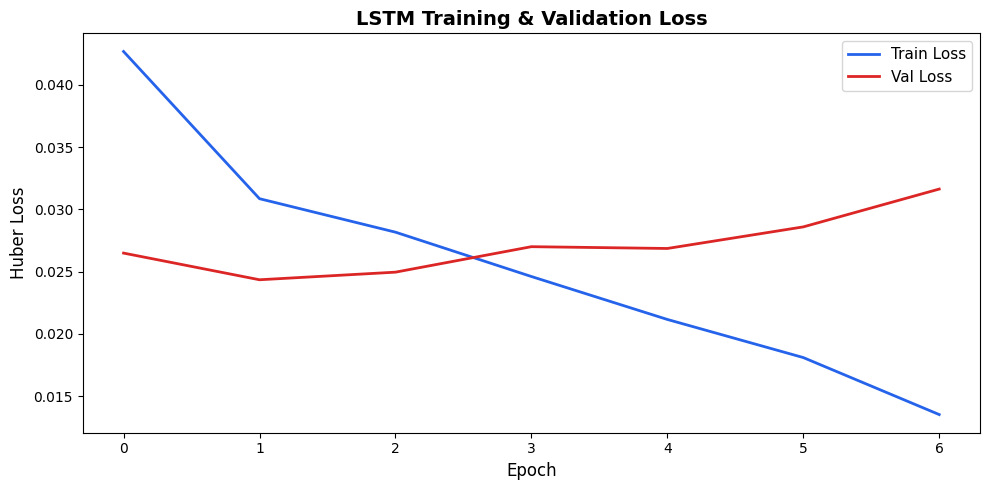

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label='Train Loss', color='#2563eb', linewidth=2)
ax.plot(val_losses,   label='Val Loss',   color='#dc2626', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Huber Loss', fontsize=12)
ax.set_title('LSTM Training & Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{ROOT}/plots/06_lstm_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Evaluate on Test Set

In [12]:
# Load best model
model.load_state_dict(torch.load(f'{ROOT}/models/lstm_best.pth', map_location=DEVICE))
model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        pred = model(xb).cpu().numpy()
        all_preds.append(pred)
        all_targets.append(yb.numpy())

preds   = np.concatenate(all_preds,   axis=0)  # (N, 24)
targets = np.concatenate(all_targets, axis=0)  # (N, 24)

# Inverse scale — only temperature column
temp_mean  = scaler.mean_[TARGET_IDX]
temp_scale = scaler.scale_[TARGET_IDX]

preds_real   = preds   * temp_scale + temp_mean
targets_real = targets * temp_scale + temp_mean

# Metrics (averaged across all 24 prediction steps)
mae  = mean_absolute_error(targets_real.flatten(), preds_real.flatten())
rmse = np.sqrt(mean_squared_error(targets_real.flatten(), preds_real.flatten()))
r2   = r2_score(targets_real.flatten(), preds_real.flatten())

print('=' * 40)
print('LSTM TEST RESULTS — JENA')
print('=' * 40)
print(f'MAE:  {mae:.4f} °C')
print(f'RMSE: {rmse:.4f} °C')
print(f'R²:   {r2:.4f}')
print('=' * 40)
print()


LSTM TEST RESULTS — JENA
MAE:  1.3584 °C
RMSE: 1.8218 °C
R²:   0.9475


## 11. Prediction vs Actual Plot

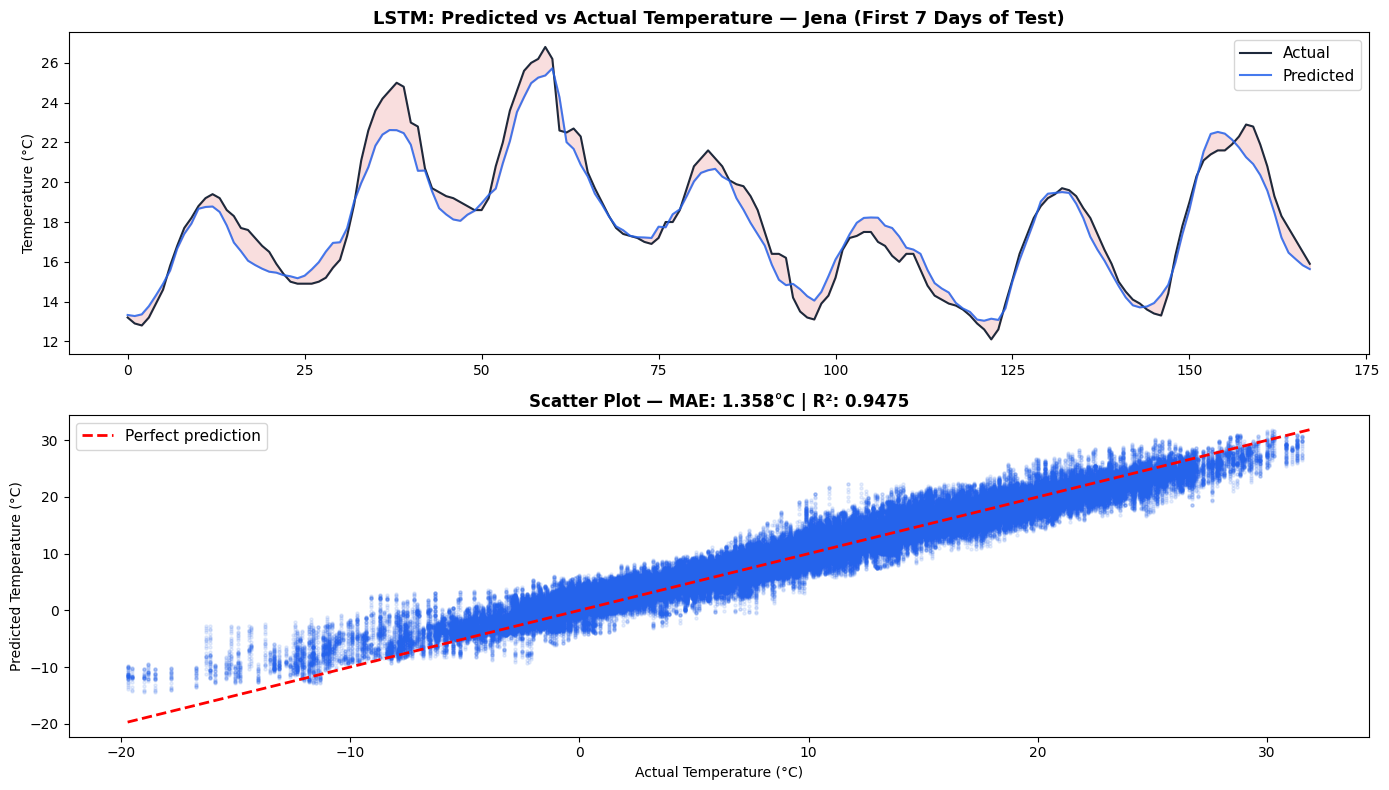

In [13]:
# Plot first 7 days of test predictions (step 1 — next hour prediction)
n_show = 168
y_true = targets_real[:n_show, 0]  # next-hour prediction
y_pred = preds_real[:n_show, 0]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Time series
ax = axes[0]
ax.plot(y_true, label='Actual',    color='#1e293b', linewidth=1.5)
ax.plot(y_pred, label='Predicted', color='#2563eb', linewidth=1.5, alpha=0.85)
ax.fill_between(range(n_show), y_true, y_pred, alpha=0.15, color='#dc2626')
ax.set_title('LSTM: Predicted vs Actual Temperature — Jena (First 7 Days of Test)', fontsize=13, fontweight='bold')
ax.set_ylabel('Temperature (°C)')
ax.legend(fontsize=11)

# Scatter
ax2 = axes[1]
ax2.scatter(targets_real.flatten(), preds_real.flatten(), alpha=0.1, s=5, color='#2563eb')
mn = min(targets_real.min(), preds_real.min())
mx = max(targets_real.max(), preds_real.max())
ax2.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect prediction')
ax2.set_xlabel('Actual Temperature (°C)')
ax2.set_ylabel('Predicted Temperature (°C)')
ax2.set_title(f'Scatter Plot — MAE: {mae:.3f}°C | R²: {r2:.4f}', fontsize=12, fontweight='bold')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig(f'{ROOT}/plots/07_lstm_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. MAE Per Forecast Horizon

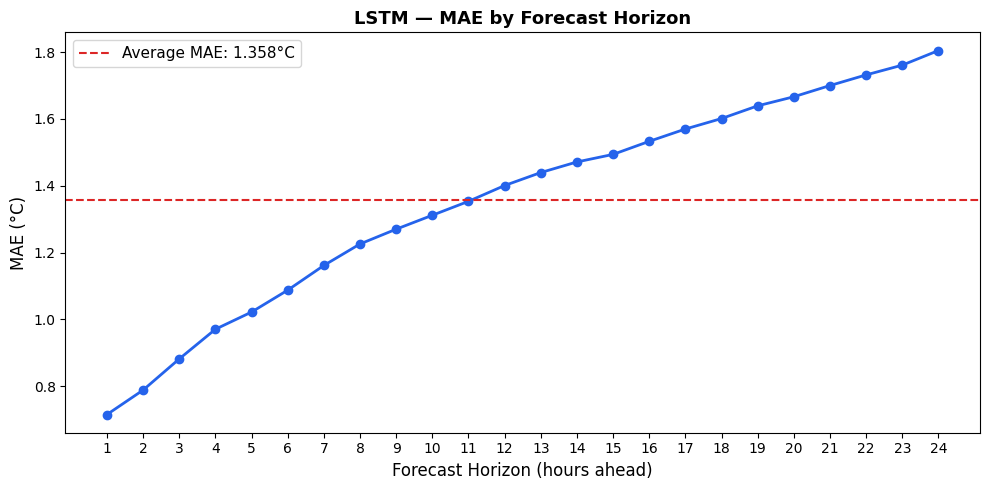

Expected: MAE increases as forecast horizon grows (harder to predict further ahead)


In [14]:
# How does accuracy degrade as we predict further ahead?
horizon_mae = [mean_absolute_error(targets_real[:, h], preds_real[:, h]) for h in range(PRED_STEPS)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, PRED_STEPS+1), horizon_mae, marker='o', color='#2563eb', linewidth=2)
ax.axhline(y=mae, color='#dc2626', linestyle='--', linewidth=1.5, label=f'Average MAE: {mae:.3f}°C')
ax.set_xlabel('Forecast Horizon (hours ahead)', fontsize=12)
ax.set_ylabel('MAE (°C)', fontsize=12)
ax.set_title('LSTM — MAE by Forecast Horizon', fontsize=13, fontweight='bold')
ax.set_xticks(range(1, PRED_STEPS+1))
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{ROOT}/plots/08_lstm_horizon_mae.png', dpi=150, bbox_inches='tight')
plt.show()
print('Expected: MAE increases as forecast horizon grows (harder to predict further ahead)')

## 13. Save Results

In [15]:
results = {
    'model':  'LSTM',
    'city':   'Jena',
    'MAE':    round(mae, 4),
    'RMSE':   round(rmse, 4),
    'R2':     round(r2, 4),
    'seq_len': SEQ_LEN,
    'pred_steps': PRED_STEPS,
    'features': len(FEATURE_COLS)
}

results_df = pd.DataFrame([results])
results_df.to_csv(f'{ROOT}/processed/model_results.csv', index=False)

print('Results saved to processed/model_results.csv')
print()
print('=' * 40)
print('NOTEBOOK 2 COMPLETE')
print('=' * 40)
print(f'MAE:  {mae:.4f} °C')
print(f'RMSE: {rmse:.4f} °C')
print(f'R²:   {r2:.4f}')
print()
print('Next: 03_tft_model.ipynb — Temporal Fusion Transformer')

Results saved to processed/model_results.csv

NOTEBOOK 2 COMPLETE
MAE:  1.3584 °C
RMSE: 1.8218 °C
R²:   0.9475

Next: 03_tft_model.ipynb — Temporal Fusion Transformer


In [16]:
# --- copy results back to Drive so they survive the session -------------------
import shutil, os, glob
os.makedirs(f'{DRIVE}/results', exist_ok=True)
saved = []
for pat in ('processed/*.csv', 'models/*.ckpt', 'models/*.pth', 'plots/*.png'):
    for p in glob.glob(f'{ROOT}/{pat}'):
        shutil.copy(p, f'{DRIVE}/results/{os.path.basename(p)}')
        saved.append(os.path.basename(p))
print('copied to Drive:', saved)


copied to Drive: ['model_results.csv', 'master_all_cities.csv', 'lstm_best.pth', '06_lstm_loss_curve.png', '08_lstm_horizon_mae.png', '07_lstm_predictions.png']
